## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import os
from bs4 import BeautifulSoup
import warnings

warnings.filterwarnings('ignore')

print("Loading datasets...")
try:
    df_train = pd.read_csv('./data/train/train.csv')
    df_test = pd.read_csv('./data/test/test.csv')
    print("Train shape:", df_train.shape)
    print("Test shape:", df_test.shape)
    print("\nSample Train Data:")
    df_train.head()
except FileNotFoundError as e:
    print("Error loading dataset:", e)

Loading datasets...
Train shape: (49972, 4)
Test shape: (25413, 3)

Sample Train Data:


## Pengecekan Data Duplikat

In [14]:
print("Jumlah Data Duplikat di Train: ", df_train.duplicated().sum())

print("Data Train Duplikat:")
display(df_train[df_train.duplicated(keep=False)].head(4))

Jumlah Data Duplikat di Train:  402
Data Train Duplikat:


,Body ID,articleBody,Headline,Stance
47,5,(NEWSER) – Wonder how long a Quarter Pounder w...,WHO says reports of suspected Ebola cases in I...,unrelated
54,5,(NEWSER) – Wonder how long a Quarter Pounder w...,WHO says reports of suspected Ebola cases in I...,unrelated
129,7,At least 25 suspected Boko Haram insurgents we...,Government fires employee who skipped work for...,unrelated
159,7,At least 25 suspected Boko Haram insurgents we...,Government fires employee who skipped work for...,unrelated


In [15]:
print("Jumlah Data Duplikat di Test: ", df_test.duplicated().sum())
print("Data Test Duplikat:")
display(df_test[df_test.duplicated(keep=False)].head(4))

Jumlah Data Duplikat di Test:  242
Data Test Duplikat:


,Body ID,articleBody,Headline
479,42,SAN FRANCISCO -- Apple plans to shut down stre...,"Wife chops off cheating husband’s penis, twice"
483,42,SAN FRANCISCO -- Apple plans to shut down stre...,"Wife chops off cheating husband’s penis, twice"
819,92,An unfortunate woman in South Korea was left i...,Charles Manson’s fiancee allegedly wanted to m...
821,92,An unfortunate woman in South Korea was left i...,Charles Manson’s fiancee allegedly wanted to m...


In [18]:
df_train_proc = df_train.drop_duplicates()
df_test_proc = df_test.drop_duplicates()

In [19]:
print("Jumlah Data Duplikat di Train: ", df_train_proc.duplicated().sum())
print("Jumlah Data Duplikat di Test: ", df_test_proc.duplicated().sum())

Jumlah Data Duplikat di Train:  0
Jumlah Data Duplikat di Test:  0


## Data Quality Before Preprocessing

In [2]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')
email_pattern = re.compile(r'\S+@\S+')
unicode_pattern = re.compile(r'[^\x00-\x7F]+')
multiple_ws_pattern = re.compile(r'\s{2,}')
punct_pattern = re.compile(r'[?!.]{4,}')

def check_quality(text):
    text = str(text)
    return pd.Series([
        bool(url_pattern.search(text)),
        bool(email_pattern.search(text)),
        bool(html_pattern.search(text)),
        bool(unicode_pattern.search(text)),
        bool(multiple_ws_pattern.search(text)),
        bool(punct_pattern.search(text))
    ])

print("Memeriksa kualitas data TRAIN sebelum preprocessing...")
train_qual = df_train['articleBody'].apply(check_quality)
train_qual.columns = ['URL', 'Email', 'HTML', 'Unicode', 'Multiple Whitespace', 'Excessive Punctuation']

print("Memeriksa kualitas data TEST sebelum preprocessing...")
test_qual = df_test['articleBody'].apply(check_quality)
test_qual.columns = train_qual.columns

qual_before_df = pd.DataFrame({
    'Train Before': train_qual.sum(),
    'Test Before': test_qual.sum()
})
display(qual_before_df)

Memeriksa kualitas data TRAIN sebelum preprocessing...
Memeriksa kualitas data TEST sebelum preprocessing...


,Train Before,Test Before
URL,1791,913
Email,3389,1082
HTML,284,304
Unicode,33002,16250
Multiple Whitespace,45417,22136
Excessive Punctuation,391,192


In [3]:
def remove_html(text):
    # Menghapus seluruh tag HTML dari teks menggunakan BeautifulSoup.
    if pd.isna(text):
        return text
    soup = BeautifulSoup(str(text), "html.parser")
    return soup.get_text(separator=" ")

## Normalisasi URL

In [4]:
def normalize_url(text):
    # Mengganti semua URL menjadi token khusus [URL].
    if pd.isna(text):
        return text
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', str(text))
    return text

## Normalisasi Email

In [5]:
def normalize_email(text):
    # Mengganti semua alamat email menjadi token khusus [EMAIL].
    if pd.isna(text):
        return text
    text = re.sub(r'\S+@\S+', '[EMAIL]', str(text))
    return text

## Normalisasi Unicode

In [6]:
def normalize_unicode(text):
    if pd.isna(text):
        return text
    return unicodedata.normalize("NFKC", str(text))

## Normalisasi Spasi

In [7]:
def normalize_whitespace(text):
    # Mengganti multiple spaces, tabs, atau newlines menjadi satu spasi.
    if pd.isna(text):
        return text
    return re.sub(r'\s+', ' ', str(text))

## Text Trimming

In [8]:
def trim_text(text):
    # Menghapus spasi di awal dan di akhir teks.
    if pd.isna(text):
        return text
    return str(text).strip()

## Full Preprocessing Pipeline

In [21]:
def preprocess_text(text):
    if pd.isna(text):
        return text
    
    text = remove_html(text)
    text = normalize_url(text)
    text = normalize_email(text)
    text = normalize_unicode(text)
    text = normalize_whitespace(text)
    text = trim_text(text)
    
    return text

## Menjalankan Preprocessing

In [22]:
print("Menerapkan preprocessing pada data TRAIN...")
df_train_proc['Headline'] = df_train_proc['Headline'].apply(preprocess_text)
df_train_proc['articleBody'] = df_train_proc['articleBody'].apply(preprocess_text)

print("Menerapkan preprocessing pada data TEST...")
df_test_proc['Headline'] = df_test_proc['Headline'].apply(preprocess_text)
df_test_proc['articleBody'] = df_test_proc['articleBody'].apply(preprocess_text)
print("Preprocessing selesai!")

Menerapkan preprocessing pada data TRAIN...
Menerapkan preprocessing pada data TEST...
Preprocessing selesai!


## Analisis Data Setelah Preprocessing

Memeriksa kualitas data TRAIN setelah preprocessing...
Memeriksa kualitas data TEST setelah preprocessing...


,Train Before,Train After,Test Before,Test After
URL,1791,0,913,0
Email,3389,0,1082,0
HTML,284,0,304,0
Unicode,33002,32287,16250,15927
Multiple Whitespace,45417,0,22136,0
Excessive Punctuation,391,545,192,339


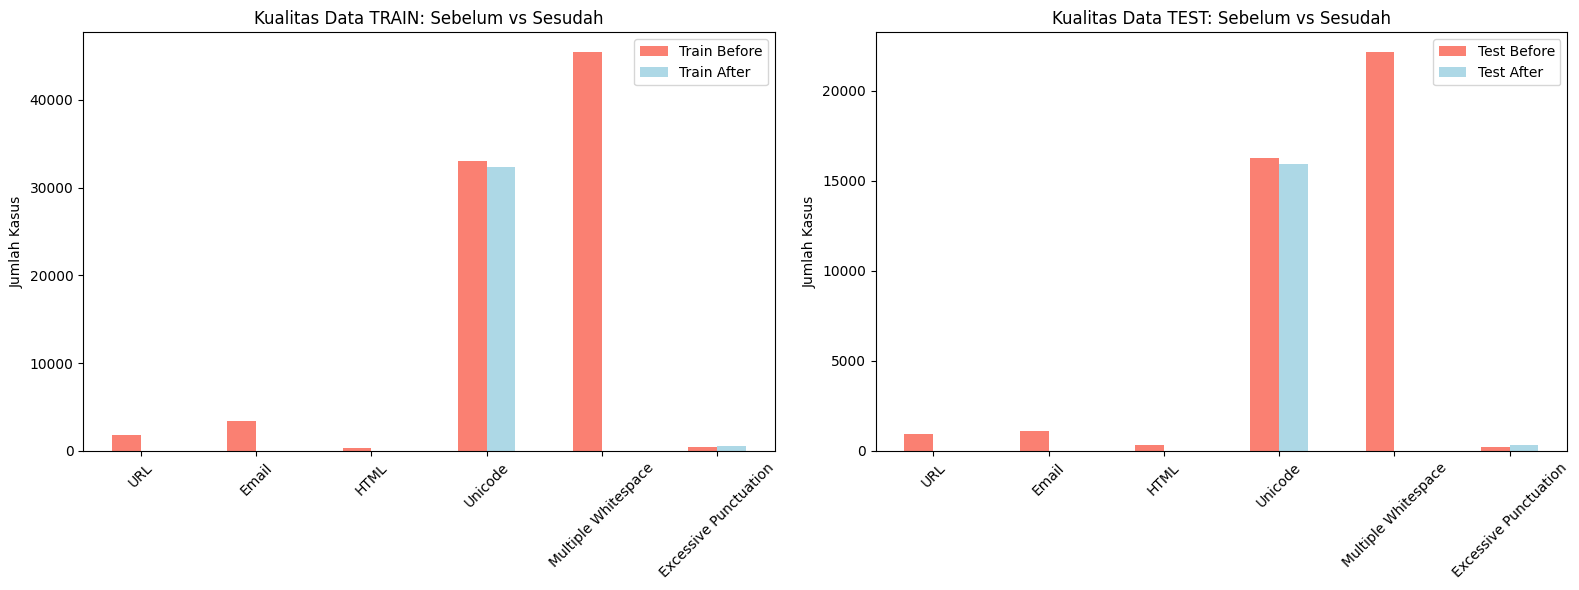

In [23]:
print("Memeriksa kualitas data TRAIN setelah preprocessing...")
train_qual_after = df_train_proc['articleBody'].apply(check_quality)
train_qual_after.columns = train_qual.columns

print("Memeriksa kualitas data TEST setelah preprocessing...")
test_qual_after = df_test_proc['articleBody'].apply(check_quality)
test_qual_after.columns = train_qual.columns

qual_after_df = pd.DataFrame({
    'Train After': train_qual_after.sum(),
    'Test After': test_qual_after.sum()
})

comparison_df = pd.concat([qual_before_df, qual_after_df], axis=1)
# Mengurutkan kolom agar lebih mudah dibaca
comparison_df = comparison_df[['Train Before', 'Train After', 'Test Before', 'Test After']]

display(comparison_df)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
comparison_df[['Train Before', 'Train After']].plot(kind='bar', ax=axes[0], color=['salmon', 'lightblue'])
axes[0].set_title('Kualitas Data TRAIN: Sebelum vs Sesudah')
axes[0].set_ylabel('Jumlah Kasus')
axes[0].tick_params(axis='x', rotation=45)

comparison_df[['Test Before', 'Test After']].plot(kind='bar', ax=axes[1], color=['salmon', 'lightblue'])
axes[1].set_title('Kualitas Data TEST: Sebelum vs Sesudah')
axes[1].set_ylabel('Jumlah Kasus')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Hasil pembersihan menunjukkan metrik URL, Email, HTML, dan spasi ganda berhasil turun menjadi nol karena elemen tersebut merupakan noise dengan pola pasti yang dapat dieliminasi secara menyeluruh menggunakan identifikasi Regular Expression. Sebaliknya, indikator Unicode masih menyisakan angka yang signifikan karena pembersihan dilakukan secara selektif; karakter yang tersisa bukanlah noise, melainkan elemen tipografi jurnalistik dan linguistik yang valid seperti tanda kutip pintar (“ ”), em-dash (—), serta huruf beraksen. Membiarkan karakter Unicode ini adalah langkah yang disengaja dan sangat tepat, karena elemen tersebut menjaga keutuhan struktur semantik kalimat yang esensial untuk mengoptimalkan performa penangkapan konteks pada model Transformer (DeBERTa, RoBERTa, XLNet).

## Contoh Perbandingan

In [24]:
print("=== Contoh Perbandingan Sebelum vs Sesudah Preprocessing ===")

# Ambil 10 sampel acak dari data train
sample_indices = df_train.sample(10, random_state=42).index

for i, idx in enumerate(sample_indices, 1):
    print(f"\n--- Sample {i} ---")
    print("[BEFORE CLEANING]")
    print(f"Headline: {df_train.loc[idx, 'Headline']}")
    print(f"Body: {df_train.loc[idx, 'articleBody'][:200]}...") # Dibatasi 200 karakter
    
    print("\n[AFTER CLEANING]")
    print(f"Headline: {df_train_proc.loc[idx, 'Headline']}")
    print(f"Body: {df_train_proc.loc[idx, 'articleBody'][:200]}...")
    print("-" * 80)

=== Contoh Perbandingan Sebelum vs Sesudah Preprocessing ===

--- Sample 1 ---
[BEFORE CLEANING]
Headline: Mum faces real-life Sophie's Choice – as she tries to sell her son to fund daughter's care
Body: (Mashable) Reports that Islamic State militants in Mosul have contracted Ebola swirled though Iraqi media sources on Wednesday. World Health Organization officials said they haven’t confirmed the case...

[AFTER CLEANING]
Headline: Mum faces real-life Sophie's Choice – as she tries to sell her son to fund daughter's care
Body: (Mashable) Reports that Islamic State militants in Mosul have contracted Ebola swirled though Iraqi media sources on Wednesday. World Health Organization officials said they haven’t confirmed the case...
--------------------------------------------------------------------------------

--- Sample 2 ---
[BEFORE CLEANING]
Headline: Dog Found Abandoned With Suitcase Filled With His Belongings
Body: Fox & Friends got very excited Thursday morning over rumors, which th

## Simpan Data yang telah diproses

In [25]:
output_dir = './data/processed/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Direktori {output_dir} berhasil dibuat.")

train_output_path = os.path.join(output_dir, 'train_processed.csv')
test_output_path = os.path.join(output_dir, 'test_processed.csv')

df_train_proc.to_csv(train_output_path, index=False)
df_test_proc.to_csv(test_output_path, index=False)

print("✅ Dataset berhasil disimpan!")
print(f"Train path: {train_output_path}")
print(f"Test path: {test_output_path}")

✅ Dataset berhasil disimpan!
Train path: ./data/processed/train_processed.csv
Test path: ./data/processed/test_processed.csv
